In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from tueplots import bundles
## use ICML style for one-column figures
plt.rcParams.update(bundles.icml2024(column="half"))

from scipy.stats import kendalltau

import glob
import re

In [10]:
# LOAD DATA

# news data on female murder/homocide
news = gpd.read_file("data/q32_filterdate-threshold.csv")

# shapefile for geo-visualizations
shapefile = gpd.read_file("data/nuts250_12-31.gk3.shape/nuts250_12-31.gk3.shape/nuts250_1231/NUTS250_N3.shp")
shapefile = shapefile.rename(columns={"NUTS_CODE" : "NUTS"})  # rename NUST variable to match news dataset

# population data (incl. "Gemeinedeschluessel" and NUTS for matching pks)
pop = pd.read_excel("data/04-kreise_bearb.xlsx")

# pks (polizeiliche kriminalstatistik) data between 2017-23

files = glob.glob("data/pks_data/*.csv")

def process_pks_file(filepath):
    # extract year from filename 
    year = re.search(r"(20\d{2})", filepath).group(1)
    short_year = year[-2:]  # "17", "18", ...

    pks = pd.read_csv(
        filepath,
        encoding="unicode_escape",
        sep=";",
        skiprows=1
    )

    pks = pks[
        (pks["Straftat"].str.contains("Mord", na=False)) &
        (pks["Fallstatus"] == "voll.") #only accomplished murder, not attempts
    ]

    # choose column containing female-victims, depending on year of the pks

    if year in ["2017", "2018"]:
        female_col = "Opfer insgesamt weiblich- Anzahl"
    else:
        female_col = "Opfer weiblich"

    # aggregate female victims per municipality
    pks = (
        pks.groupby(
            ["Gemeindeschluessel", "Stadt/Landkreis"],
            as_index=False
        )[female_col]
        .sum()
        .rename(columns={female_col: f"fem{short_year}"})
    )

    return pks

pks_tot = [process_pks_file(f) for f in files]


C:\Users\Wolandt\AppData\Local\Temp\ipykernel_316\2064378541.py:22: DtypeWarning: Columns (0,18,21,22,26,27,28,29,31,32,35,38,43,44,46,47,65) have mixed types. Specify dtype option on import or set low_memory=False.
  pks = pd.read_csv(
C:\Users\Wolandt\AppData\Local\Temp\ipykernel_316\2064378541.py:22: DtypeWarning: Columns (0,6,18,21,22,24,25,26,27,28,29,30,31,32,35,38,43,44,46,47,50,53,59,62,64,65) have mixed types. Specify dtype option on import or set low_memory=False.
  pks = pd.read_csv(
C:\Users\Wolandt\AppData\Local\Temp\ipykernel_316\2064378541.py:22: DtypeWarning: Columns (0,12,13,14,15,16,17,20,23,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  pks = pd.read_csv(
C:\Users\Wolandt\AppData\Local\Temp\ipykernel_316\2064378541.py:22: DtypeWarning: Columns (0,12,13,14,16,17,20,23,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  pks = pd.read_csv(
C:\Users\Wolandt\AppData\Local\Temp\ipykernel_316\2064378541.py:2

In [3]:
# PREPARE PKS DATASET (add NUTS, convert to long format)

from functools import reduce

pks_fem = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on=["Gemeindeschluessel", "Stadt/Landkreis"],
        how="outer"
    ),
    pks_tot
)

# add NUTS code to pks_fem, based on Gemeindeschluessel by merging with population data

# ensure keys have same dtype
pks_fem["Gemeindeschluessel"] = pks_fem["Gemeindeschluessel"].astype(str)
pop["off_reg_key"] = pop["off_reg_key"].astype(str)

# check overlap
common_keys = set(pks_fem["Gemeindeschluessel"]) & set(pop["off_reg_key"])
print(f"Common keys: {len(common_keys)}")
print(f"PKS only: {pks_fem.shape[0] - len(common_keys)}")
print(f"POP only: {pop.shape[0] - len(common_keys)}")

pks_fem = pks_fem.merge(
    pop[["off_reg_key", "NUTS"]],
    left_on="Gemeindeschluessel",
    right_on="off_reg_key",
    how="left",
    validate="m:1" 
)

# drop redundant key
pks_fem = pks_fem.drop(columns="off_reg_key")

# convert to long data format

fem_cols = [c for c in pks_fem.columns if c.startswith("fem")]

pks_fem_long = pks_fem.melt(
    id_vars=["Gemeindeschluessel", "Stadt/Landkreis", "NUTS"],
    value_vars=fem_cols,
    var_name="year",
    value_name="fem"
)

pks_fem_long["year"] = (
    pks_fem_long["year"]
    .str.replace("fem", "", regex=False)
    .astype(int)
    .add(2000)
)

pks_fem_long

Common keys: 400
PKS only: 2
POP only: 0


,Gemeindeschluessel,Stadt/Landkreis,NUTS,year,fem
0,1001,Flensburg,DEF01,2017,0
1,1002,Kiel,DEF02,2017,1
2,1003,Lübeck,DEF03,2017,2
3,1004,Neumünster,DEF04,2017,0
4,1051,Dithmarschen,DEF05,2017,1
...,...,...,...,...,...
2809,16073,Saalfeld-Rudolstadt,DEG0U,2023,1
2810,16074,Saale-Holzland-Kreis,DEG0J,2023,0
2811,16075,Saale-Orla-Kreis,DEG0K,2023,0
2812,16076,Greiz,DEG0L,2023,0


In [4]:
# DATASET EXPLORATION NEWS LOCATIONS

print("news data rows:", len(news))
print("shapefile rows:", len(shapefile))

# check, whether NUTS in news data correspond to actual german NUTS

nuts_news = set(news['NUTS'].unique())
nuts_shapefile  = set(shapefile['NUTS'].unique())

nuts_only_in_news = sorted(list(nuts_news - nuts_shapefile))
nuts_only_in_shapefile  = sorted(list(nuts_shapefile - nuts_news))

print("Unique NUTS in news:", len(nuts_news))
print("Unique NUTS in shapefile: ", len(nuts_shapefile))
print("NUTS in news but NOT in shapefile:", nuts_only_in_news)#, "corresponding to locations:", news["loc_normal"])
print("Number of NUTS in news but not in shapefile:", len(nuts_only_in_news))
print("NUTS in shapefile but NOT in news:", nuts_only_in_shapefile)
print("Number of NUTS in shapefile but not in news:", len(nuts_only_in_shapefile))




news data rows: 73899
shapefile rows: 429
Unique NUTS in news: 394
Unique NUTS in shapefile:  400
NUTS in news but NOT in shapefile: ['', 'DEG04', 'DEG0B', 'DEG0F', 'DEG0I', 'DEG0P']
Number of NUTS in news but not in shapefile: 6
NUTS in shapefile but NOT in news: ['DE227', 'DE229', 'DE245', 'DE934', 'DEB24', 'DEC06', 'DEG0Q', 'DEG0R', 'DEG0S', 'DEG0T', 'DEG0U', 'DEG0V']
Number of NUTS in shapefile but not in news: 12


In [5]:
# RECODE NUTS IN NEWS DATA AND FILTER SO THAT ONLY GERMAN NUTS REMAIN

# Recode NUTS in news to conform with NUTS code in shapefile

nuts_recode = {
    "DEG04": "DEG0S",
    "DEG0B": "DEG0Q",
    "DEG0F": "DEG0T",
    "DEG0I": "DEG0U",
    "DEG0P": "DEG0R",
}

news = news.copy()
news["NUTS"] = news["NUTS"].replace(nuts_recode)

# filter news data so that only articles with matching NUTS remain (i.e., filters out Non-german articles or articles without location)

news_filtered = news[news["NUTS"].isin(nuts_shapefile)].copy()

print("Rows before filtering:", len(news))
print("Rows after filtering:", len(news_filtered))
print("Number of unique articles:", len(news_filtered["id"].value_counts())) 


# news_filtered["id"].value_counts() #for exploring duplicates


Rows before filtering: 73899
Rows after filtering: 65436
Number of unique articles: 31368


In [6]:
# COMBINE NEWS DATA WITH DATA ON ACTUAL FEMALE VICTIMS OF MURDER

news_filtered['date'] = pd.to_datetime(news_filtered['date'], errors='coerce')
news_filtered = news_filtered.dropna(subset=['date']).copy()
news_filtered['year'] = news_filtered['date'].dt.year.astype(int)

news_year_nuts = (
    news_filtered
    .groupby(["NUTS", "year"])["id"]
    .nunique()
    .reset_index(name="news_count")
)

# merge news data with actual femicide data

pks_fem_news = pks_fem_long.merge(
    news_year_nuts,
    on=["NUTS", "year"],
    how="left",
    validate="m:1"
)

pks_fem_news["fem"] = pks_fem_news["fem"].fillna(0).astype(int)
pks_fem_news["news_count"] = pks_fem_news["news_count"].fillna(0).astype(int)

pks_fem_news

,Gemeindeschluessel,Stadt/Landkreis,NUTS,year,fem,news_count
0,1001,Flensburg,DEF01,2017,0,11
1,1002,Kiel,DEF02,2017,1,42
2,1003,Lübeck,DEF03,2017,2,25
3,1004,Neumünster,DEF04,2017,0,5
4,1051,Dithmarschen,DEF05,2017,1,0
...,...,...,...,...,...,...
2809,16073,Saalfeld-Rudolstadt,DEG0U,2023,1,1
2810,16074,Saale-Holzland-Kreis,DEG0J,2023,0,2
2811,16075,Saale-Orla-Kreis,DEG0K,2023,0,0
2812,16076,Greiz,DEG0L,2023,0,0


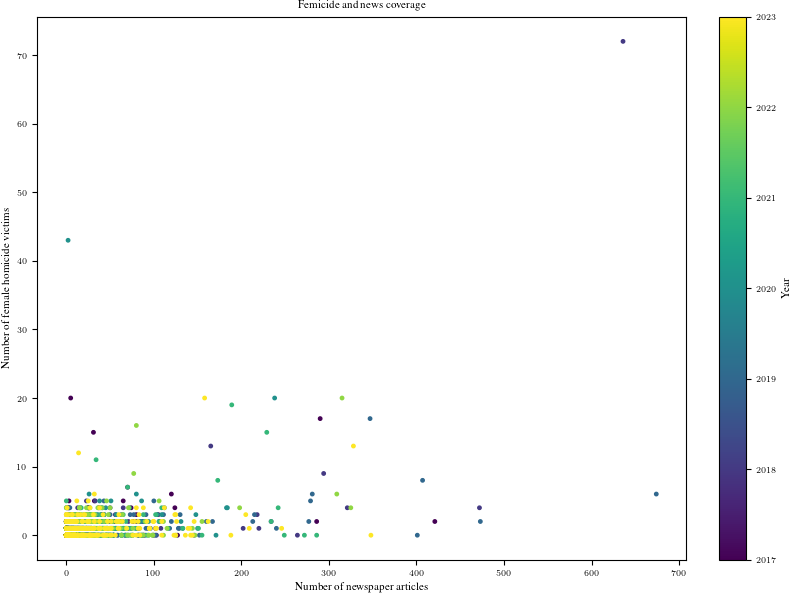

In [7]:
# SCATTERPLOT NEWS COUNT VS. ACTUAL FEMICIDES

pks_fem_news["year"] = pd.to_numeric(pks_fem_news["year"], errors="coerce")
pks_fem_news["fem"] = pd.to_numeric(pks_fem_news["fem"], errors="coerce")
pks_fem_news["news_count"] = pd.to_numeric(pks_fem_news["news_count"], errors="coerce")

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    pks_fem_news["news_count"],
    pks_fem_news["fem"],
    c=pks_fem_news["year"],
    s=6
)

plt.xlabel("Number of newspaper articles")
plt.ylabel("Number of female homicide victims")
plt.title("Femicide and news coverage")

plt.colorbar(scatter, label="Year")
plt.show()



In [ ]:
# SAVE DATA TO BE USED FOR STATISTICAL ANALYSIS IN R

# make a clean export copy
df_export = pks_fem_news.copy()

# keep only variables needed for R
df_export = df_export[
    ["NUTS", "year", "news_count", "fem", "pop22_tot"]
]

# save to CSV
df_export.to_csv(
    "data/pks_fem_news_for_R.csv",
    index=False
)
